In [1]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import gzip
import json

import matplotlib
import pickle

import torch

from sklearn.manifold import TSNE

import sys; sys.path.insert(0, '..')
from sepsis_models.models.autoencoder import *
from sepsis_models.preprocessing.dataset import *
from sepsis_models.derived_information.neighbors import get_nearest_neighbors
from sepsis_models.derived_information.descriptive import DescriptiveInformation
from sepsis_models.derived_information.predictive import PredictiveActionDependentInformation, PredictiveActionIndependentInformation
from sepsis_models.derived_information.prescriptive import PrescriptiveOutcomeInformation, PrescriptivePeerInformation
from sepsis_models.derived_information.uncommon import UncommonActionsInformation
from sepsis_models.derived_information.patient_info import create_state_dict, demog_features, state_features
from sepsis_models.derived_information.utils import TREATMENT_INFO
from utils import convert_to_native_types

from google.cloud import storage

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Update these
data_dir = "../../sepsis-ai-modeling/250125_condensed_variables"
model_dir = "../../sepsis-ai-modeling/250125_condensed_variables/feature_weighted_autoencoder"

In [3]:
AS_IS_COLUMNS = []
LOG_NORM_COLUMNS = [
    "SpO2", "BUN", "Creatinine", "AST", "ALT", 
    "Total Bili", "Direct Bili", "INR", "Input Last 24 h", "Output Last 24 h",
    "Hypertonic Crystalloid", "Hypotonic Crystalloid", "Isotonic Crystalloid",
    "Blood Products", "Isotonic Colloid",
    "Dopamine", "Epinephrine", "Norepinephrine", "Vasopressin", "Phenylephrine"
]

COMORBIDITIES = [
    'congestive_heart_failure', 'cardiac_arrhythmias', 'valvular_disease',
    'pulmonary_circulation', 'peripheral_vascular', 'hypertension',
    'paralysis', 'other_neurological', 'chronic_pulmonary',
    'diabetes_uncomplicated', 'diabetes_complicated', 'hypothyroidism',
    'renal_failure', 'liver_disease', 'peptic_ulcer',
    'aids', 'lymphoma', 'metastatic_cancer',
    'solid_tumor', 'rheumatoid_arthritis', 'coagulopathy',
    'obesity', 'weight_loss', 'fluid_electrolyte',
    'blood_loss_anemia', 'deficiency_anemias', 'alcohol_abuse',
    'drug_abuse', 'psychoses', 'depression'
]

EXCLUDE_COLUMNS = []

def format_states(df, scaler=None, all_columns=None):
    global AS_IS_COLUMNS, LOG_NORM_COLUMNS, EXCLUDE_COLUMNS
    dummies = pd.get_dummies(df, 
                        columns=[c for c in df.columns 
                                if pd.api.types.is_object_dtype(df[c].dtype) 
                                or pd.api.types.is_string_dtype(df[c].dtype) 
                                or isinstance(df[c].dtype, pd.CategoricalDtype)])
    if all_columns is not None:
        dummies = dummies.assign(**{c: np.zeros(len(dummies), dtype=np.uint8)
                                    for c in all_columns if c not in dummies.columns})
    if scaler is None:
        EXCLUDE_COLUMNS = [c for c in dummies.columns
                           if (('O2 Delivery Device' in c or c.startswith("Heart Rhythm")) and dummies[c].mean() < 0.01) or
                           c.endswith("Present")]
        dummies = dummies.drop(columns=EXCLUDE_COLUMNS)
        AS_IS_COLUMNS = ["id", "intime", "Invasive Ventilation", "Non-invasive Ventilation",
                 *[c for c in dummies.columns 
                   if "_" in c or 
                   " Present" in c or 
                   c.endswith("Current") or 
                   c.endswith("Ever") or 
                   (c.startswith("Positive") and c.endswith("Culture")) or 
                   c in COMORBIDITIES]]
        
        scaler = DataNormalization(dummies,
                                      as_is_columns=AS_IS_COLUMNS,
                                      log_norm_columns=LOG_NORM_COLUMNS,
                                      norm_columns=[c for c in dummies.columns if c not in AS_IS_COLUMNS + LOG_NORM_COLUMNS])
        return scaler.transform(dummies).assign(id=dummies['id'], intime=dummies['intime']), scaler, dummies.columns
    return scaler.transform(dummies.drop(columns=[c for c in EXCLUDE_COLUMNS if c in dummies.columns])).assign(id=dummies['id'], intime=dummies['intime'])
    
def create_treatments(split, past=False, encode=False):
    treatments = pd.concat([
        pd.read_csv(os.path.join(data_dir, "past_treatments" if past else "treatments", "fluids", f"{split}.csv"), index_col=0),
        pd.read_csv(os.path.join(data_dir, "past_treatments" if past else "treatments", "vaso", f"{split}.csv"), index_col=0).drop(columns=["id", "intime"]),
    ], axis=1)
    treatments.columns = ["id", "intime", "fluid", "vaso"]
    treatments['vaso'] = treatments['vaso'].fillna(0).astype(int)
    treatments['fluid'] = treatments['fluid'].fillna(0).astype(int)
    # if past:
    #     treatments['fluid'] = treatments['fluid'].groupby(treatments["id"]).shift(1)
    #     treatments['vaso'] = treatments['vaso'].groupby(treatments["id"]).shift(1)
    if encode:
        return treatments['fluid'] * 3 + treatments['vaso']
    return treatments.drop(columns=["id", "intime"])

train_df, normalizer, all_cols = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_train.csv"), index_col=0))
train_df = train_df.clip(-10, 10).assign(id=train_df['id'], intime=train_df['intime'])
val_df = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_val.csv"), index_col=0), scaler=normalizer, all_columns=all_cols)
val_df = val_df.clip(-10, 10).assign(id=val_df['id'], intime=val_df['intime'])
test_df = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_test.csv"), index_col=0), scaler=normalizer, all_columns=all_cols)
test_df = test_df.clip(-10, 10).assign(id=test_df['id'], intime=test_df['intime'])
print("Excluding columns:", EXCLUDE_COLUMNS)

train_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "train.csv"), index_col=0).values[:,-1]
val_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "val.csv"), index_col=0).values[:,-1]
test_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "test.csv"), index_col=0).values[:,-1]
train_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "train.csv"), index_col=0).values[:,-1]
val_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "val.csv"), index_col=0).values[:,-1]
test_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "test.csv"), index_col=0).values[:,-1]

# filter inputs to exclude patients who have less than 1 urine observation per day on average
train_mask = ~train_uo.astype(bool) & ~train_cmo.astype(bool) # pd.isna(train_y).groupby(train_df['id']).transform("sum") < max_missing
val_mask = ~val_uo.astype(bool) & ~val_cmo.astype(bool) # pd.isna(val_y).groupby(val_df['id']).transform("sum") < max_missing
test_mask = ~test_uo.astype(bool) & ~test_cmo.astype(bool) # pd.isna(test_y).groupby(test_df['id']).transform("sum") < max_missing

# CHANGED HERE: include only up to 7 days per patient
max_steps = np.round(np.quantile(train_df.groupby('id').size(), 0.95)) # 42
print('max steps:', max_steps)
min_days = 0.5
time_res = 4
train_mask &= ((train_df['intime'].groupby(train_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
              & (pd.Series(train_mask, index=train_df.index).groupby(train_df['id']).transform("sum") >= min_days * 24 / time_res))
val_mask &= ((val_df['intime'].groupby(val_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
            & (pd.Series(val_mask, index=val_df.index).groupby(val_df['id']).transform("sum") >= min_days * 24 / time_res))
test_mask &= ((test_df['intime'].groupby(test_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
             & (pd.Series(test_mask, index=test_df.index).groupby(test_df['id']).transform("sum") >= min_days * 24 / time_res))

# CHANGED: remove patients who never receive any treatment
treatments_train = create_treatments('train')
treatments_val = create_treatments('val')
treatments_test = create_treatments('test')
# train_mask &= ~((treatments_train['fluid'] == 0) & (treatments_train['vaso'] == 0)).groupby(train_df['id']).transform('all')
# val_mask &= ~((treatments_val['fluid'] == 0) & (treatments_val['vaso'] == 0)).groupby(val_df['id']).transform('all')
# test_mask &= ~((treatments_test['fluid'] == 0) & (treatments_test['vaso'] == 0)).groupby(test_df['id']).transform('all')

# TEMPORARY: sample test IDs
# np.random.seed(1234)
# test_sample_ids = np.random.choice(test_df['id'].unique(), size=2000, replace=False)
# test_mask &= test_df['id'].isin(test_sample_ids)

print("Before:", len(train_df), len(val_df), len(test_df))
train_df = train_df[train_mask].reset_index(drop=True)
val_df = val_df[val_mask].reset_index(drop=True)
test_df = test_df[test_mask].reset_index(drop=True)

treatments_train = treatments_train[train_mask].reset_index(drop=True)
treatments_val = treatments_val[val_mask].reset_index(drop=True)
treatments_test = treatments_test[test_mask].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

Excluding columns: ['ALT Present', 'AST Present', 'Arterial BE Present', 'Arterial pH Present', 'BUN Present', 'Bicarbonate Present', 'CO2 Calc Present', 'CVP Present', 'Calcium Present', 'Chloride Present', 'Creatinine Present', 'DiaBP Present', 'Direct Bili Present', 'FiO2 Present', 'GCS Eye Opening Present', 'GCS Motor Response Present', 'GCS Verbal Response Present', 'Glucose Present', 'Heart Rate Present', 'Hematocrit Present', 'Hemoglobin Present', 'INR Present', 'Ionized Ca Present', 'Lactic Acid Present', 'Magnesium Present', 'Mean Airway Pressure Present', 'Minute Volume Present', 'O2 Flow Present', 'PAPdia Present', 'PAPmean Present', 'PAPsys Present', 'PEEP Present', 'PT Present', 'PTT Present', 'PaCO2 Present', 'PaO2 Present', 'Peak Inspiratory Pressure Present', 'Plateau Pressure Present', 'Platelet Count Present', 'Potassium Present', 'RASS Present', 'Respiratory Rate Present', 'Sodium Present', 'SpO2 Present', 'SysBP Present', 'Temperature C Present', 'Tidal Volume Prese

In [4]:
best_param_set = {'architecture': 'transformer', 
                  'nencoder': 4, 
                  'nhead': 8, 
                  'nhid': 128, 
                  'nembed': 32, 
                  'lr': 0.001, 
                  'dropout': 0.1, 
                  'lr_decay': 0.98, 
                  'n_warmup': 4, 
                  'mask_gamma': 1.01}

model_trainer = TimeSeriesAutoencoderTrainer(
    train_df,
    val_df,
    test_df,
    time_col='intime',
    device='cpu',
    first_value_reconstruction=True,
    past_value_reconstruction=True,
    checkpoint_path=os.path.join(model_dir, f"weighted_transformer.pt"),
    **best_param_set
)

# model_trainer.fit(epochs=50, patience=200, batch_size=32)
model_trainer.load_checkpoint()

In [5]:
past_treatments_train = create_treatments('train', past=True, encode=True)[train_mask]
past_treatments_val = create_treatments('val', past=True, encode=True)[val_mask]
past_treatments_test = create_treatments('test', past=True, encode=True)[test_mask]

In [6]:
# example: nearest neighbors of the validation set instances in the training set
neighborhoods_dir = os.path.join(data_dir, "neighborhoods")
if not os.path.exists(neighborhoods_dir): os.mkdir(neighborhoods_dir)

if not os.path.exists(os.path.join(neighborhoods_dir, "train_neighbors.pkl")):
    train_encoded = model_trainer.encode(model_trainer.train_dataset)
    val_encoded = model_trainer.encode(model_trainer.val_dataset)
    test_encoded = model_trainer.encode(model_trainer.test_dataset)
    train_neighb_train, train_neighb_dist_train = get_nearest_neighbors(train_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    reference_identical=True,
                                                                    stratify=(past_treatments_train, past_treatments_train))
    val_neighb_train, val_neighb_dist_train = get_nearest_neighbors(val_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    stratify=(past_treatments_val, past_treatments_train))
    test_neighb_train, test_neighb_dist_train = get_nearest_neighbors(test_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    stratify=(past_treatments_test, past_treatments_train))

    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "wb") as file:
        pickle.dump((train_neighb_train, train_neighb_dist_train), file)
    with open(os.path.join(neighborhoods_dir, "val_neighbors.pkl"), "wb") as file:
        pickle.dump((val_neighb_train, val_neighb_dist_train), file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "wb") as file:
        pickle.dump((test_neighb_train, test_neighb_dist_train), file)
else:
    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "rb") as file:
        train_neighb_train, train_neighb_dist_train = pickle.load(file)
    with open(os.path.join(neighborhoods_dir, "val_neighbors.pkl"), "rb") as file:
        val_neighb_train, val_neighb_dist_train = pickle.load(file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "rb") as file:
        test_neighb_train, test_neighb_dist_train = pickle.load(file)
    

In [7]:
severity_scores_train = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "train.csv"), index_col=0).iloc[:,-1].values
severity_scores_train = severity_scores_train[train_mask]
severity_scores_val = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "val.csv"), index_col=0).iloc[:,-1].values
severity_scores_val = severity_scores_val[val_mask]
severity_scores_test = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "test.csv"), index_col=0).iloc[:,-1].values
severity_scores_test = severity_scores_test[test_mask]

severity_cutoffs = np.quantile(severity_scores_train, np.linspace(0, 1, 9))
print("SOFA score cutoffs:", severity_cutoffs)
train_severity_quantiles = np.digitize(severity_scores_train, severity_cutoffs[:-1]) - 1
val_severity_quantiles = np.digitize(severity_scores_val, severity_cutoffs[:-1]) - 1
test_severity_quantiles = np.digitize(severity_scores_test, severity_cutoffs[:-1]) - 1

SOFA score cutoffs: [ 0.  4.  5.  6.  7.  8.  9. 11. 23.]


# Inverse Probability Treatment Weighting

The treatment in our setting is 1 if the patient's treatment at each timestep is equal to the one recommended by our AI, and 0 otherwise.

First train two XGBoost models: one to predict the probability of each possible treatment given all the covariates, and another to predict the same thing given only the constant features. Then we calculate the probabilities of being equal to the AI recommended treatment for each step. The weight for each timestep will be the latter probability divided by the former.

In [47]:
import xgboost

tx_flattener = lambda t: t['fluid'] * 3 + t['vaso']
flattened_treatments_train = pd.DataFrame(tx_flattener(treatments_train))
flattened_treatments_val = pd.DataFrame(tx_flattener(treatments_val))
flattened_treatments_test = pd.DataFrame(tx_flattener(treatments_test))

static_cols = ['age', 'height', 'weight', 'gender_female', *COMORBIDITIES]

all_inputs_train = train_df.drop(columns=['id', 'intime'])
static_inputs_train = train_df.drop_duplicates('id').reset_index(drop=True)[static_cols]
all_tx_outputs_train = flattened_treatments_train
static_tx_outputs_train = flattened_treatments_train.assign(id=train_df['id']).drop_duplicates('id').reset_index(drop=True).drop(columns=['id'])
all_inputs_val = val_df.drop(columns=['id', 'intime'])
static_inputs_val = val_df.drop_duplicates('id').reset_index(drop=True)[static_cols]
all_tx_outputs_val = flattened_treatments_val
static_tx_outputs_val = flattened_treatments_val.assign(id=val_df['id']).drop_duplicates('id').reset_index(drop=True).drop(columns=['id'])
all_inputs_test = test_df.drop(columns=['id', 'intime'])
static_inputs_test = test_df.drop_duplicates('id').reset_index(drop=True)[static_cols]
all_tx_outputs_test = flattened_treatments_test
static_tx_outputs_test = flattened_treatments_test.assign(id=test_df['id']).drop_duplicates('id').reset_index(drop=True).drop(columns=['id'])
print(all_inputs_train.shape, static_inputs_train.shape, all_tx_outputs_train.shape, static_tx_outputs_train.shape)
print(all_inputs_val.shape, static_inputs_val.shape, all_tx_outputs_val.shape, static_tx_outputs_val.shape)
print(all_inputs_test.shape, static_inputs_test.shape, all_tx_outputs_test.shape, static_tx_outputs_test.shape)

(391946, 185) (14000, 34) (391946, 1) (14000, 1)
(202905, 185) (7065, 34) (202905, 1) (7065, 1)
(196345, 185) (6937, 34) (196345, 1) (6937, 1)


In [48]:
if os.path.exists(os.path.join(model_dir, "260804_all_tx_xgb.json")):
    all_tx_model = xgboost.XGBClassifier()
    all_tx_model.load_model(os.path.join(model_dir, "260804_all_tx_xgb.json"))
else:
    all_tx_model = xgboost.XGBClassifier()
    all_tx_model.fit(all_inputs_train, all_tx_outputs_train)
    all_tx_model.save_model(os.path.join(model_dir, "260804_all_tx_xgb.json"))
print("With all covariates:", all_tx_model.score(all_inputs_val, all_tx_outputs_val))

if os.path.exists(os.path.join(model_dir, "260804_static_tx_xgb.json")):
    static_tx_model = xgboost.XGBClassifier()
    static_tx_model.load_model(os.path.join(model_dir, "260804_static_tx_xgb.json"))
else:
    static_tx_model = xgboost.XGBClassifier()
    static_tx_model.fit(static_inputs_train, static_tx_outputs_train)
    static_tx_model.save_model(os.path.join(model_dir, "260804_static_tx_xgb.json"))
print("Static covariates only:", static_tx_model.score(static_inputs_val, static_tx_outputs_val))

With all covariates: 0.7767526675044972
Static covariates only: 0.28520877565463554


In [49]:
# Get the recommended outputs for each instance. Some timesteps have no recommendation
# because none of the treatment actions were taken frequently enough - exclude these
train_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "train.csv"), index_col=0).iloc[:,-1].values[train_mask]
ai_clinician = PrescriptiveOutcomeInformation(train_neighb_train, 
                                              train_df['id'].astype(int), 
                                              train_outcome, 
                                              treatments_train.values, 
                                              severity_cutoffs)

all_plan_model = PredictiveActionDependentInformation(train_neighb_train, 
                                              train_df['id'].astype(int), 
                                              train_outcome, 
                                              treatments_train.values, 
                                              severity_cutoffs)

recs_val = []
plans_val = []
recs_test = []
plans_test = []
for i in tqdm.tqdm(range(len(val_df))):
    rec = ai_clinician.get_recommendation(
                            val_neighb_train[i], 
                            val_severity_quantiles[i])
    if not rec: 
        recs_val.append({'fluid': None, 'vaso': None})
        plans_val.append({})
    else:
        recs_val.append({
            'fluid': TREATMENT_INFO[0]['short_names'].index(rec['recommendation'][0]['value']),
            'vaso': TREATMENT_INFO[1]['short_names'].index(rec['recommendation'][1]['value'])
        })
        plans = all_plan_model.get_prediction(
                            val_neighb_train[i], 
                            val_severity_quantiles[i], min_frequency=0.05)
        plan_fluids = np.array([TREATMENT_INFO[0]['short_names'].index(p['policy'][0]['value']) for p in plans['predictions']])
        plan_vaso = np.array([TREATMENT_INFO[1]['short_names'].index(p['policy'][1]['value']) for p in plans['predictions']])
        plans_val.append({
            f * 3 + v: 1
            for f, v in zip(plan_fluids, plan_vaso)
        })
for i in tqdm.tqdm(range(len(test_df))):
    rec = ai_clinician.get_recommendation(
                            test_neighb_train[i], 
                            test_severity_quantiles[i])
    if not rec: 
        recs_test.append({'fluid': None, 'vaso': None})
        plans_test.append({})
    else:
        recs_test.append({
            'fluid': TREATMENT_INFO[0]['short_names'].index(rec['recommendation'][0]['value']),
            'vaso': TREATMENT_INFO[1]['short_names'].index(rec['recommendation'][1]['value'])
        })
        plans = all_plan_model.get_prediction(
                            test_neighb_train[i], 
                            test_severity_quantiles[i], min_frequency=0.05)
        plan_fluids = np.array([TREATMENT_INFO[0]['short_names'].index(p['policy'][0]['value']) for p in plans['predictions']])
        plan_vaso = np.array([TREATMENT_INFO[1]['short_names'].index(p['policy'][1]['value']) for p in plans['predictions']])
        plans_test.append({
            f * 3 + v: 1
            for f, v in zip(plan_fluids, plan_vaso)
        })
recs_val = tx_flattener(pd.DataFrame(recs_val))
recs_test = tx_flattener(pd.DataFrame(recs_test))
plans_val = pd.DataFrame(plans_val)
plans_test = pd.DataFrame(plans_test)
print(recs_val.value_counts(), plans_val.mean(axis=0))

100%|██████████| 196345/196345 [01:03<00:00, 3087.08it/s]


9.0     67721
0.0     57458
3.0     54788
4.0      8666
10.0     7738
1.0      1997
5.0      1422
11.0      840
8.0       485
7.0       226
6.0       114
2.0        11
Name: count, dtype: int64 0     1.0
3     1.0
6     1.0
9     1.0
4     1.0
7     1.0
8     1.0
10    1.0
1     1.0
5     1.0
11    1.0
2     1.0
dtype: float64


0.010227965 78.23104


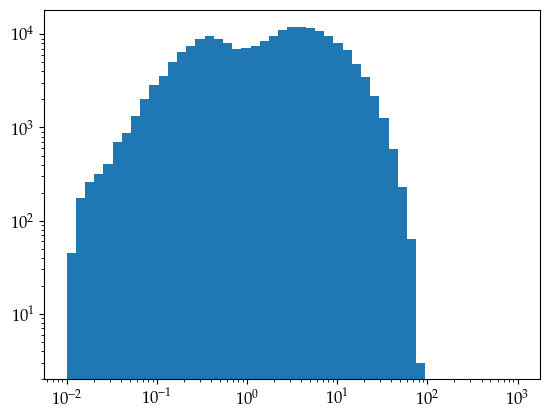

In [50]:
# Calculate IPTW
val_rec_mask = ~pd.isna(recs_val)
test_rec_mask = ~pd.isna(recs_test)

static_treatment_probs_val = static_tx_model.predict_proba(all_inputs_val[val_rec_mask][static_cols])
static_treatment_probs_val = static_treatment_probs_val + 0.01
static_treatment_probs_val /= static_treatment_probs_val.sum(axis=1, keepdims=True)
static_treatment_probs_val = static_treatment_probs_val[np.arange(val_rec_mask.sum()),recs_val[val_rec_mask].astype(int)]
all_treatment_probs_val = all_tx_model.predict_proba(all_inputs_val[val_rec_mask])
all_treatment_probs_val = all_treatment_probs_val + 0.01
all_treatment_probs_val /= all_treatment_probs_val.sum(axis=1, keepdims=True)
all_treatment_probs_val = all_treatment_probs_val[np.arange(val_rec_mask.sum()),recs_val[val_rec_mask].astype(int)]
iptw_val = np.clip(static_treatment_probs_val / all_treatment_probs_val, 0.01, 1000)

static_treatment_probs_test = static_tx_model.predict_proba(all_inputs_test[test_rec_mask][static_cols])
static_treatment_probs_test = static_treatment_probs_test + 0.01
static_treatment_probs_test /= static_treatment_probs_test.sum(axis=1, keepdims=True)
static_treatment_probs_test = static_treatment_probs_test[np.arange(test_rec_mask.sum()),recs_test[test_rec_mask].astype(int)]
all_treatment_probs_test = all_tx_model.predict_proba(all_inputs_test[test_rec_mask])
all_treatment_probs_test = all_treatment_probs_test + 0.01
all_treatment_probs_test /= all_treatment_probs_test.sum(axis=1, keepdims=True)
all_treatment_probs_test = all_treatment_probs_test[np.arange(test_rec_mask.sum()),recs_test[test_rec_mask].astype(int)]
iptw_test = np.clip(static_treatment_probs_test / all_treatment_probs_test, 0.01, 1000)

print(iptw_val.min(), iptw_val.max())
plt.figure()
plt.hist(iptw_val, bins=np.logspace(-2, 3, 50))
plt.loglog()
plt.show()

In [14]:
regression_dir = os.path.join(model_dir, "iptw_regression")
if not os.path.exists(regression_dir):
    os.mkdir(regression_dir)
    
pd.Series(iptw_val).to_csv(os.path.join(regression_dir, "iptw_val.csv"), index=False)
pd.Series(iptw_test).to_csv(os.path.join(regression_dir, "iptw_test.csv"), index=False)

def simple_covariates(df, severity, concordance):
    print(len(df), len(concordance))
    simple_df = pd.DataFrame({
        **{c: df[c] for c in df.columns},
        'id': df['id'].astype(int),
        'timestep': (df['intime'] - df.groupby('id')['intime'].transform('min')) / (3600 * 4),
        # **{c: df[c] for c in ['gender_female', 'age', 'weight', 'height']},
        # 'elixhauser': df[COMORBIDITIES].sum(axis=1),
        'sofa': severity,
        'concordance': concordance
    })
    print(len(simple_df))
    return simple_df

simple_covariates(val_df[val_rec_mask].reset_index(drop=True), 
                  severity_scores_val[val_rec_mask],
                  (recs_val[val_rec_mask] == flattened_treatments_val[val_rec_mask].iloc[:,0]).reset_index(drop=True)).to_csv(os.path.join(regression_dir, "all_inputs_val.csv"), index=False, float_format='%.4g')
simple_covariates(test_df[test_rec_mask].reset_index(drop=True), 
                  severity_scores_test[test_rec_mask],
                  (recs_test[test_rec_mask] == flattened_treatments_test[test_rec_mask].iloc[:,0]).reset_index(drop=True)).to_csv(os.path.join(regression_dir, "all_inputs_test.csv"), index=False, float_format='%.4g')

val_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "val.csv"), index_col=0).iloc[:,-1].values[val_mask]
test_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "test.csv"), index_col=0).iloc[:,-1].values[test_mask]
pd.Series(val_outcome[val_rec_mask]).to_csv(os.path.join(regression_dir, "outcome_val.csv"), index=False)
pd.Series(test_outcome[test_rec_mask]).to_csv(os.path.join(regression_dir, "outcome_test.csv"), index=False)

201466 201466
201466
195836 195836
195836


# Complexity Metrics

1. Number of abnormal lab categories >= 5
2. Unusualness according to model (distance greater than 0.75 quantile)
   - Note: the original code selected by the inverse (distance less than 0.25 quantile) due to an error, so the list of cases from which the vignettes were selected was not quite aligned with our definition of complexity. However, using the correct unusualness metric also includes all of the vignette patients.
3. Spread in plausible decisions >= 3 (also check number of plausible decisions)

In [56]:
RANGES_BY_SYSTEM = {
    "Cardiac": {
        "Lactic Acid": { "min": 0.5, "max": 1.6 },
        "Troponin": { "max": 1 }, # not sure what these units are
    },
    "Coags": {
        "PTT": { "min": 60, "max": 70 },
        "PT": { "min": 11, "max": 13.5 },
        "INR": { "min": 0.8, "max": 1.1 },
    },
    "ABGs": {
        "Arterial pH": { "min": 7.35, "max": 7.45 },
        "Arterial BE": { "min": -4, "max": 2 },
        "PaO2": { "min": 75, "max": 100 },
        "PaCO2": { "min": 35, "max": 45 },
        "Bicarbonate": { "min": 20, "max": 32 },
    },
    "CBC": {
        "WBC Count": { "min": 4.5, "max": 11 },
        "Hemoglobin": { "male": { "min": 14.0, "max": 17.5 },
                        "female": { "min": 12.3, "max": 15.3 }},
        "Hematocrit": { "male": { "min": 41, "max": 50 },
                        "female": { "min": 36, "max": 48 }},
        "Platelet Count": { "min": 130, "max": 400 },
    },
    "Liver": {
        "AST": { "female": { "min": 9, "max": 25 }, "male": { "min": 10, "max": 40 } },
        "ALT": { "female": { "min": 7, "max": 30 }, "male": { "min": 10, "max": 55 } },
        "Total Bili": { "min": -1, "max": 5 },
        "Direct Bili": { "min": -1, "max": 2 },
    },
    "Chemistries": {
        "Potassium": { "min": 3.4, "max": 5 },
        "Sodium": { "min": 135, "max": 145 },
        "Chloride": { "min": 95, "max": 108 },
        "Glucose": { "min": 110, "max": 180 },
        "Ionized Ca": { "min": 1.1, "max": 1.4 },
    },
    "Renal": {
        "BUN": { "min": 8, "max": 25 },
        "Creatinine": {
            "female": { "min": 0.6, "max": 1.8 },
            "male": { "min": 0.8, "max": 2.4 },
          },
    },
    "Neuro": {
        "GCS Eye Opening": { "min": 3, "max": 6 },
        "GCS Motor Response": { "min": 3, "max": 7 },
        "GCS Verbal Response": { "min": 3, "max": 6 },
        "RASS": { "min": -3, "max": 2 }
    }
}

def _assign_bin_values(col_data, bin_spec):
    lower = bin_spec.get("min", np.quantile(col_data, 0.25))
    upper = bin_spec.get("max", np.quantile(col_data, 0.75))
    assert lower < upper, f"{bin_spec}"
    return np.digitize(col_data, [lower, upper]) != 1

EXTREME_VALUE_BIN_NAMES = {"normal": 0, "abnormal": 1}
def extreme_value_binning(col_name, norm_range, col_data, gender_data):
    if "female" in norm_range:
        return np.where(gender_data, 
                        _assign_bin_values(col_data, norm_range["female"]),
                        _assign_bin_values(col_data, norm_range["male"])), EXTREME_VALUE_BIN_NAMES
    return _assign_bin_values(col_data, norm_range), EXTREME_VALUE_BIN_NAMES

def get_abnormal_flags(states):
    abnormal_flags = []
    abnormal_flags_system = {}
    for system, system_ranges in RANGES_BY_SYSTEM.items():
        system_flags = np.vstack([
            np.logical_and(extreme_value_binning(lab_name, range_info, states[lab_name], states['gender_female'])[0],
                           states[f'{lab_name} Present'])
            for lab_name, range_info in system_ranges.items()
        ]).T
        # for lab_name, range_info in system_ranges.items():
        #     print(lab_name, range_info, states[states['id'] == 32581623][lab_name].iloc[4], system_flags[states['id'] == 32581623][4])
        abnormal_flags.append(pd.DataFrame(system_flags, columns=list(system_ranges.keys())))
        abnormal_flags_system[system] = system_flags.any(axis=1)
    abnormal_flags = pd.concat(abnormal_flags, axis=1)
    abnormal_flags_system = pd.DataFrame(abnormal_flags_system)
    abnormal_flags['id'] = states['id']
    abnormal_flags['intime'] = states['intime']
    abnormal_flags_system['id'] = states['id']
    abnormal_flags_system['intime'] = states['intime']
    return abnormal_flags, abnormal_flags_system

abnormal_flags_val = get_abnormal_flags(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_val.csv"), index_col=0)[val_mask].reset_index(drop=True)[val_rec_mask])[1]
abnormal_flags_test = get_abnormal_flags(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_test.csv"), index_col=0)[test_mask].reset_index(drop=True)[test_rec_mask])[1]
print(abnormal_flags_val.mean(axis=0))

Cardiac        9.383717e-02
Coags          1.867213e-01
ABGs           2.551349e-01
CBC            2.773917e-01
Liver          6.240755e-02
Chemistries    3.986231e-01
Renal          2.140113e-01
Neuro          4.654830e-01
id             3.494773e+07
intime         5.801100e+09
dtype: float64


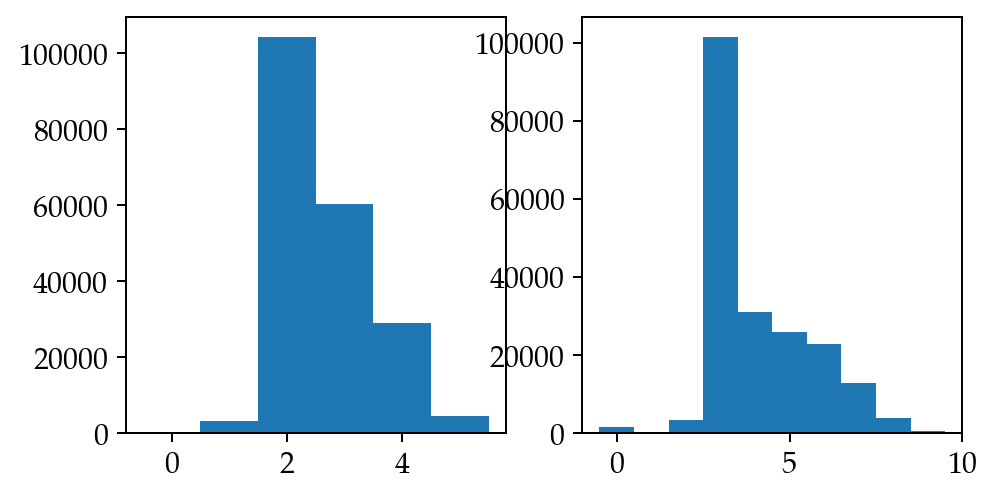

In [57]:
# Calculate the max spread in the decisions that are present
def max_spread(row):
    fluid_decs = (((row[row > 0].index // 3) + 1) % 4).values # adjust so that diuretics are first
    vaso_decs = (row[row > 0].index % 3).values
    if len(fluid_decs) == 0: return float('nan')
    diffs = np.abs(fluid_decs[:,None] - fluid_decs[None,:]) + np.abs(vaso_decs[:,None] - vaso_decs[None,:])
    return diffs.max()

plan_spread_val = plans_val.apply(max_spread, axis=1)
plan_spread_test = plans_test.apply(max_spread, axis=1)
plan_count_val = plans_val.sum(axis=1)
plan_count_test = plans_test.sum(axis=1)

plt.figure(figsize=(6, 3), dpi=180)
plt.subplot(121)
plt.hist(plan_spread_val, bins=np.arange(-0.5, 6.5))
plt.subplot(122)
plt.hist(plan_count_val, bins=np.arange(-0.5, 10.5))
plt.show()

In [58]:
# Unusualness according to model

unusualness_cutoff = np.quantile(train_neighb_dist_train[:,-1][~np.isnan(train_neighb_dist_train[:,-1])], 0.9)
unusual_flag_val = (val_neighb_dist_train[:,-1] >= unusualness_cutoff)[val_rec_mask]
unusual_flag_test = (test_neighb_dist_train[:,-1] >= unusualness_cutoff)[test_rec_mask]

test_ids = [36443311, 33742242, 32581623, 33097931, 37967458, 38885783]
[t for t in test_ids if t in test_df[test_rec_mask][unusual_flag_test]['id'].astype(int).unique()]

[36443311, 33742242, 32581623, 33097931, 37967458, 38885783]

In [ ]:
# Write all complexity metrics to a file
complex_val = val_df[val_rec_mask][['id', 'intime']].reset_index(drop=True).assign(
    high_spread=plan_spread_val >= 3,
    many_options=plan_count_val >= 5,
    unusual=unusual_flag_val,
    abnormal=abnormal_flags_val.drop(columns=['id', 'intime']).sum(axis=1) >= 6
)
complex_test = test_df[test_rec_mask][['id', 'intime']].reset_index(drop=True).assign(
    high_spread=plan_spread_test >= 3,
    many_options=plan_count_test >= 5,
    unusual=unusual_flag_test,
    abnormal=abnormal_flags_test.drop(columns=['id', 'intime']).sum(axis=1) >= 6
)
# complex_val.to_csv(os.path.join(regression_dir, "complex_flags_val.csv"))
# complex_test.to_csv(os.path.join(regression_dir, "complex_flags_test.csv"))

NameError: name 'regression_dir' is not defined

In [103]:
print("any:", complex_test[['high_spread', 'many_options', 'abnormal']].any(axis=1).mean())
print("all:", complex_test[['high_spread', 'many_options', 'abnormal']].all(axis=1).mean())
print("plan-based:", complex_test[['high_spread', 'many_options']].all(axis=1).mean())

print(complex_test[['high_spread', 'many_options', 'abnormal']].mean(axis=0))
print(complex_test[complex_test[['high_spread', 'many_options', 'abnormal']].any(axis=1)]['id'].nunique(), complex_test['id'].nunique())

print("total:", len(complex_test), len(complex_test['id'].unique()))
for flag in ['high_spread', 'many_options', 'abnormal']:
    print(flag, complex_test[flag].sum(), len(complex_test[complex_test[flag]]['id'].unique()))
print("SOFA >= 10:", (severity_scores_test[test_rec_mask] >= 10).sum(), complex_test[(severity_scores_test[test_rec_mask] >= 10)]['id'].nunique())

any: 0.10263179395003982
all: 0.0013531730631753099
plan-based: 0.01929165219877857
high_spread     0.037531
many_options    0.020589
abnormal        0.066576
dtype: float64
4379 6937
total: 195836 6937
high_spread 7350 2648
many_options 4032 1824
abnormal 13038 3358
SOFA >= 10: 46458 2675


In [71]:
test_ids = [36443311, 33742242, 32581623, 33097931, 37967458, 38885783]
for col in ['high_spread', 'many_options', 'abnormal']: 
    print([t for t in test_ids if t in complex_test[complex_test[col]]['id'].astype(int).unique()])

[36443311, 33742242, 33097931]
[36443311, 33097931]
[36443311, 33742242, 33097931, 38885783]


In [60]:
plan_spread_test.value_counts()

1.0    104455
0.0     50398
2.0     33613
3.0      6107
4.0      1248
5.0        15
Name: count, dtype: int64

In [79]:
# How are the decisions themselves different within each category?

def make_fluid_comparisons(true, pred):
    true = (true + 1) % 4
    pred = (pred + 1) % 4
    return pd.Series(np.where(true > pred, 'more fluid', np.where(true < pred, 'less fluid', 'same')))

def make_vaso_comparisons(true, pred):
    return pd.Series(np.where(true > pred, 'more vasopressor', np.where(true < pred, 'less vasopressor', 'same')))

fluid_comparisons_base = make_fluid_comparisons(
    treatments_test[test_rec_mask]['fluid'].values,
    recs_test[test_rec_mask].values // 3)
vaso_comparisons_base = make_vaso_comparisons(
    treatments_test[test_rec_mask]['vaso'].values,
    recs_test[test_rec_mask].values % 3)

fluid_comparisons_base.value_counts(), vaso_comparisons_base.value_counts()

(same          139112
 more fluid     29666
 less fluid     27058
 Name: count, dtype: int64,
 same                178098
 more vasopressor     14714
 less vasopressor      3024
 Name: count, dtype: int64)

In [81]:
complex_test = complex_test.assign(high_severity=(severity_scores_test[test_rec_mask] >= 10))

for flag in ['abnormal', 'high_spread', 'many_options', 'high_severity']:
    print(flag)
    fluid_comparisons_comp = make_fluid_comparisons(
        treatments_test[test_rec_mask]['fluid'].values[complex_test[flag]],
        recs_test[test_rec_mask].values[complex_test[flag]] // 3)
    vaso_comparisons_comp = make_vaso_comparisons(
        treatments_test[test_rec_mask]['vaso'].values[complex_test[flag]],
        recs_test[test_rec_mask].values[complex_test[flag]] % 3)
    fluid_summary = pd.concat([
        fluid_comparisons_base.value_counts(normalize=True).rename('base'),
        fluid_comparisons_comp.value_counts(normalize=True).rename('comparison')
    ], axis=1)
    vaso_summary = pd.concat([
        vaso_comparisons_base.value_counts(normalize=True).rename('base'),
        vaso_comparisons_comp.value_counts(normalize=True).rename('comparison')
    ], axis=1)
    fluid_summary['proportion'] = fluid_summary['comparison'] / fluid_summary['base']
    vaso_summary['proportion'] = vaso_summary['comparison'] / vaso_summary['base']
    print(fluid_summary)
    print(vaso_summary)
    print("")

abnormal
                base  comparison  proportion
same        0.710349    0.613438    0.863572
more fluid  0.151484    0.258705    1.707807
less fluid  0.138167    0.127857    0.925383
                      base  comparison  proportion
same              0.909424    0.825203    0.907391
more vasopressor  0.075134    0.144040    1.917107
less vasopressor  0.015441    0.030756    1.991793

high_spread
                base  comparison  proportion
same        0.710349    0.706667    0.994815
more fluid  0.151484    0.150884    0.996042
less fluid  0.138167    0.142449    1.030994
                      base  comparison  proportion
same              0.909424    0.901633    0.991432
more vasopressor  0.075134    0.079592    1.059328
less vasopressor  0.015441    0.018776    1.215913

many_options
                base  comparison  proportion
same        0.710349    0.702629    0.989131
more fluid  0.151484    0.152282    1.005267
less fluid  0.138167    0.145089    1.050104
                

# Plotting (after running R code)

In [87]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

ors_df = pd.read_csv(os.path.join(regression_dir, "regression_mortality_estimates.csv"))
ors_df['label'] = ors_df['label'].replace({'High Spread': 'High Option Variance'})
ors_df

,Unnamed: 0,label,OR,lower.OR,upper.OR,p.value,group,contrast,estimate,SE,z.ratio
0,concordanceTrue,Overall,0.873754,0.797542,0.957250,0.003752,NaN,NaN,NaN,NaN,NaN
1,...2,High Option Variance,0.865652,0.789162,0.949556,0.002238,no,True - False,-0.144273,0.047200,-3.056643
2,...3,High Option Variance,1.111355,0.842565,1.465891,0.454837,yes,True - False,0.105580,0.141267,0.747375
3,...4,Many Options,0.867929,0.791870,0.951293,0.002469,no,True - False,-0.141645,0.046792,-3.027130
4,...5,Many Options,1.217289,0.844485,1.754670,0.291898,yes,True - False,0.196627,0.186558,1.053968
5,...6,Abnormal Labs,0.842326,0.765453,0.926920,0.000441,no,True - False,-0.171588,0.048826,-3.514249
6,...7,Abnormal Labs,1.110522,0.938014,1.314756,0.223577,yes,True - False,0.104830,0.086133,1.217071
7,...8,High SOFA,0.867873,0.776728,0.969713,0.012305,no,True - False,-0.141710,0.056610,-2.503283
8,...9,High SOFA,0.899769,0.775746,1.043619,0.162782,yes,True - False,-0.105618,0.075670,-1.395776


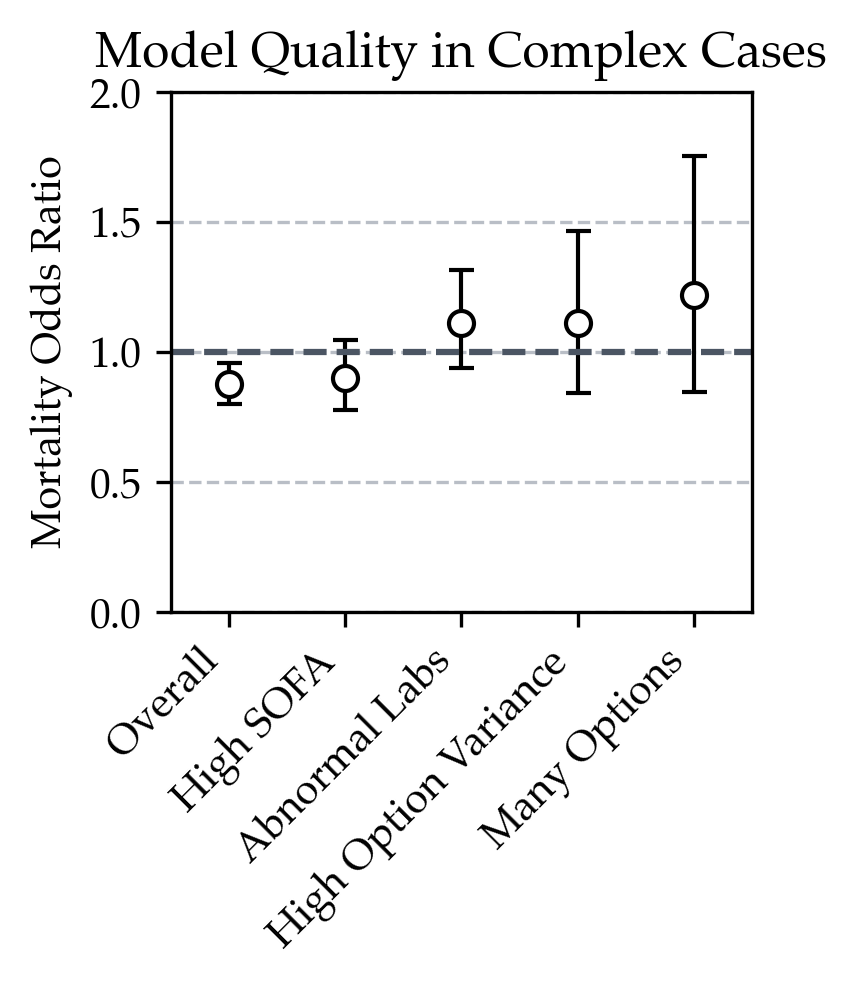

In [105]:
plt.figure(figsize=(2.5, 2.25), dpi=300)

rows_to_plot = [0, 8, 6, 2, 4]
labels = []
for i, row_idx in enumerate(rows_to_plot):
    row = ors_df.iloc[row_idx]
    plt.errorbar(y=[row['OR']], x=[i], yerr=np.array([[row['OR'] - row['lower.OR'], row['upper.OR'] - row['OR']]]).T, ecolor='k', elinewidth=1, capsize=3, fmt='o', mfc='white', mec='k')
    labels.append(row['label'])
plt.ylim(0, 2)
plt.ylabel("Mortality Odds Ratio")
plt.xlim(-0.5, len(labels) - 0.5)
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
plt.axhline(1, color='#4b5563', linestyle='--')
plt.gca().grid(visible=True, axis='y', which='major', color='#9ca3af', linestyle='--', alpha=0.7)
plt.title("Model Quality in Complex Cases")
plt.savefig(os.path.join(regression_dir, "complex_case_plot.svg"))

# Utilities

In [49]:
' + '.join(x.replace(' ', '.').replace('-', '.').replace('/', '.').replace('(', '.').replace(')', '.') for x in val_df.columns.tolist())

'id + intime + Invasive.Ventilation + Non.invasive.Ventilation + Cardioversion.Defibrillation.Current + Cardioversion.Defibrillation.Ever + Dialysis.Current + Dialysis.Ever + Positive.Blood.Culture + Positive.Culture + Positive.Sputum.Culture + Positive.Stool.Culture + Positive.Swab.Culture + Positive.Tissue.Culture + Positive.Urine.Culture + aids + alcohol_abuse + blood_loss_anemia + cardiac_arrhythmias + chronic_pulmonary + coagulopathy + congestive_heart_failure + deficiency_anemias + depression + diabetes_complicated + diabetes_uncomplicated + drug_abuse + fluid_electrolyte + gender_female + hypertension + hypothyroidism + liver_disease + lymphoma + metastatic_cancer + obesity + other_neurological + paralysis + peptic_ulcer + peripheral_vascular + psychoses + pulmonary_circulation + renal_failure + rheumatoid_arthritis + solid_tumor + valvular_disease + weight_loss + Heart.Rhythm_1st.AV..First.degree.AV.Block. + Heart.Rhythm_A.Flut..Atrial.Flutter. + Heart.Rhythm_AF..Atrial.Fibrill

In [88]:
', '.join("'" + x.replace(' ', '.').replace('-', '.').replace('/', '.').replace('(', '.').replace(')', '.') + "'" for x in val_df.columns.tolist())

"'id', 'intime', 'Invasive.Ventilation', 'Non.invasive.Ventilation', 'Cardioversion.Defibrillation.Current', 'Cardioversion.Defibrillation.Ever', 'Dialysis.Current', 'Dialysis.Ever', 'Positive.Blood.Culture', 'Positive.Culture', 'Positive.Sputum.Culture', 'Positive.Stool.Culture', 'Positive.Swab.Culture', 'Positive.Tissue.Culture', 'Positive.Urine.Culture', 'aids', 'alcohol_abuse', 'blood_loss_anemia', 'cardiac_arrhythmias', 'chronic_pulmonary', 'coagulopathy', 'congestive_heart_failure', 'deficiency_anemias', 'depression', 'diabetes_complicated', 'diabetes_uncomplicated', 'drug_abuse', 'fluid_electrolyte', 'gender_female', 'hypertension', 'hypothyroidism', 'liver_disease', 'lymphoma', 'metastatic_cancer', 'obesity', 'other_neurological', 'paralysis', 'peptic_ulcer', 'peripheral_vascular', 'psychoses', 'pulmonary_circulation', 'renal_failure', 'rheumatoid_arthritis', 'solid_tumor', 'valvular_disease', 'weight_loss', 'Heart.Rhythm_1st.AV..First.degree.AV.Block.', 'Heart.Rhythm_A.Flut..A

In [ ]:
val_rec_mask = ~pd.isna(recs_val)
all_inputs_val[val_rec_mask][static_cols]

,age,height,weight,gender_female,congestive_heart_failure,cardiac_arrhythmias,valvular_disease,pulmonary_circulation,peripheral_vascular,hypertension,...,coagulopathy,obesity,weight_loss,fluid_electrolyte,blood_loss_anemia,deficiency_anemias,alcohol_abuse,drug_abuse,psychoses,depression
0,0.470056,-0.207872,-0.136894,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.470056,-0.207872,-0.136894,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.470056,-0.207872,-0.136894,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.470056,-0.207872,-0.136894,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.470056,-0.207872,-0.136894,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202896,0.780980,0.056967,0.931163,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
202897,0.780980,0.056967,0.931163,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
202898,0.470056,0.388016,-0.796930,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
202902,0.470056,0.388016,-0.796930,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Calculate the 

# Other Plots

In [92]:
import umap

# test_encoded = model_trainer.encode(model_trainer.test_dataset)
np.random.seed(1234)
sample_indexes = np.random.choice(len(test_encoded), size=20000)
encodings_mapped = umap.UMAP(n_neighbors=50, n_epochs=1000, verbose=True, metric='cosine').fit_transform(test_encoded[sample_indexes])
# encodings_pca = PCA().fit_transform(encodings)

/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(angular_rp_forest=True, metric='cosine', n_epochs=1000, n_neighbors=50, verbose=True)
Wed Aug 12 08:34:54 2026 Construct fuzzy simplicial set
Wed Aug 12 08:34:55 2026 Finding Nearest Neighbors
Wed Aug 12 08:34:55 2026 Building RP forest with 12 trees
Wed Aug 12 08:34:55 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Wed Aug 12 08:34:56 2026 Finished Nearest Neighbor Search
Wed Aug 12 08:34:56 2026 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Wed Aug 12 08:35:08 2026 Finished embedding


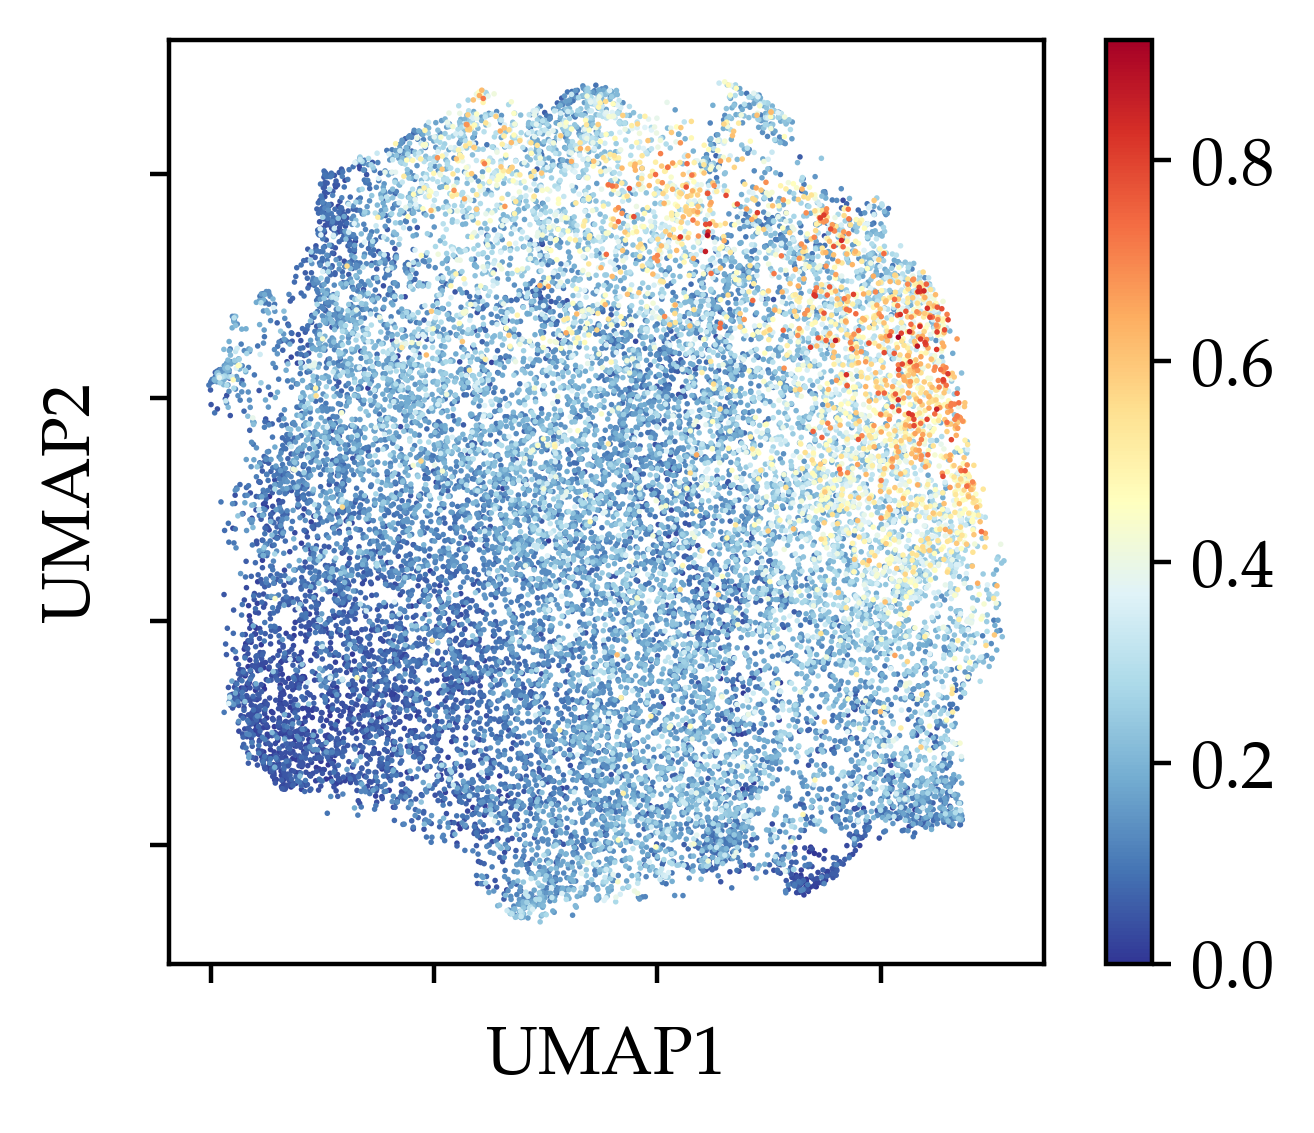

In [100]:
matplotlib.rc('font', size=12, family='Palatino')

train_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "train.csv"), index_col=0).iloc[:,-1].values[train_mask]
prob_comparisons = np.zeros(len(sample_indexes))
for i, idx in enumerate(sample_indexes):
    prob_comparisons[i] = train_outcome[test_neighb_train[idx]].mean()

plt.figure(figsize=(4, 3), dpi=400)
# plt.hexbin(encodings_mapped[:,0], encodings_mapped[:,1], gridsize=80, C=prob_comparisons, lw=0, cmap='RdYlBu_r', vmin=0)
render_order = np.argsort(prob_comparisons)
plt.scatter(encodings_mapped[:,0][render_order], encodings_mapped[:,1][render_order], c=prob_comparisons[render_order], s=1, lw=0, cmap='RdYlBu_r', vmin=0)
plt.gca().set_aspect(1.0)
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar()
plt.savefig(os.path.join(model_dir, "mortality_risk_test_set.svg"))
plt.show()

In [68]:
len(train_df) + len(val_df), len(train_df['id'].unique()) + len(val_df['id'].unique())

(594851, 21065)

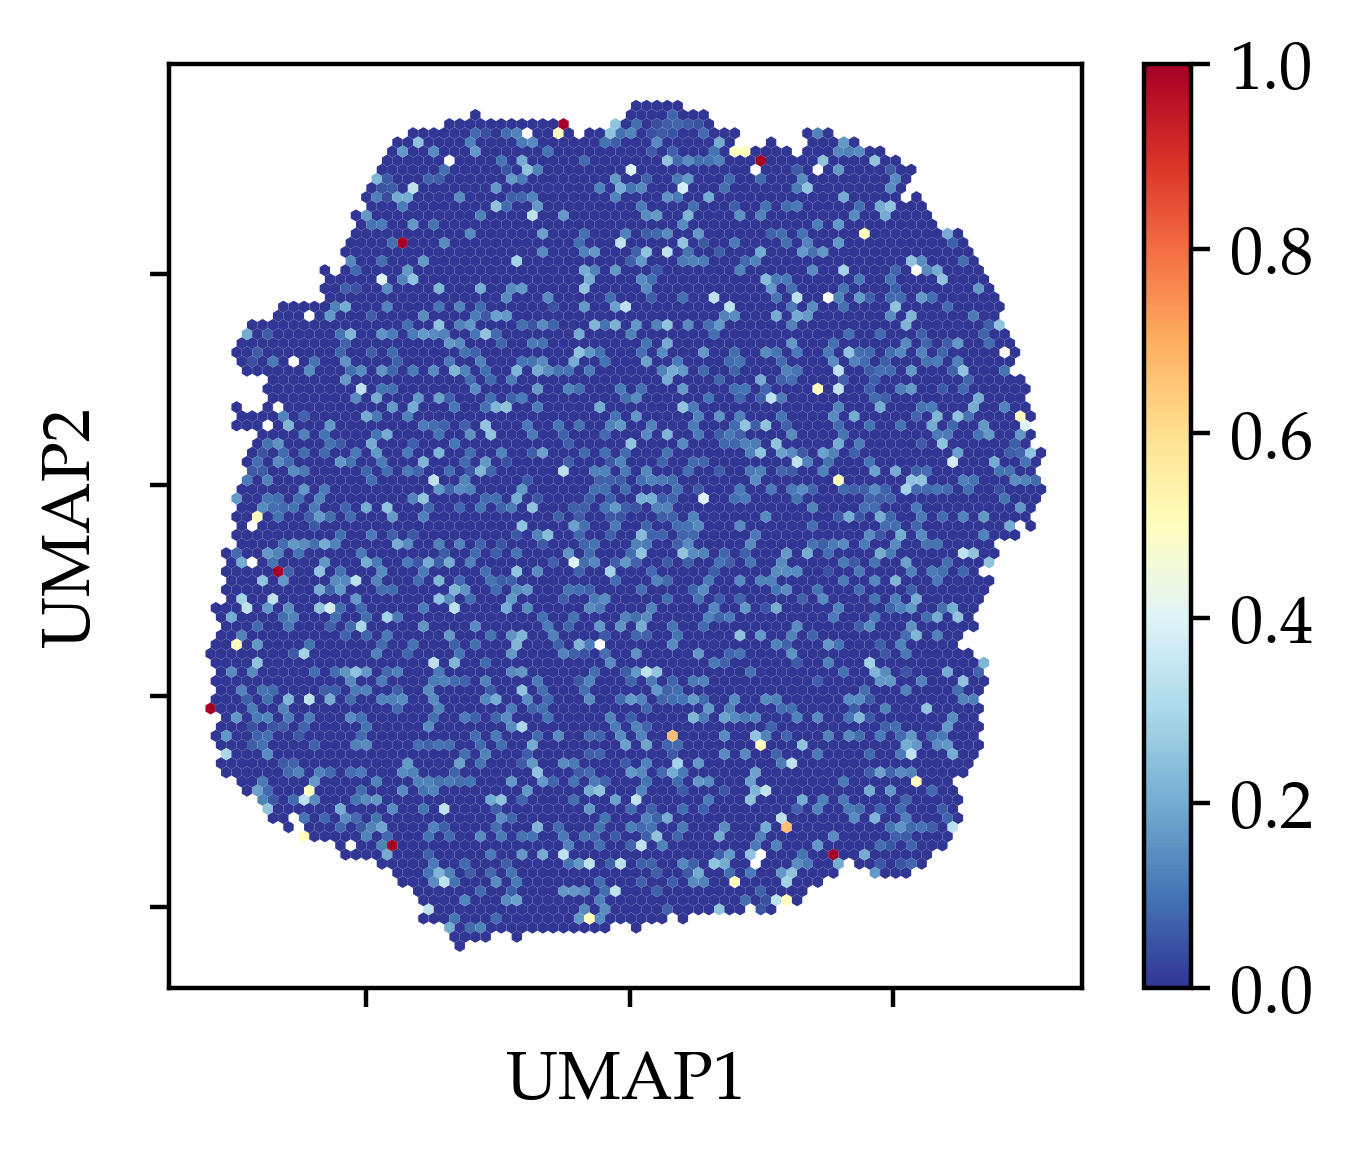

In [66]:
all_complex_flags = np.zeros(len(test_rec_mask))
all_complex_flags[test_rec_mask] = complex_test['high_spread'].values

plt.figure(figsize=(4, 3), dpi=400)
plt.hexbin(encodings_mapped[:,0][test_rec_mask[sample_indexes].values], encodings_mapped[:,1][test_rec_mask[sample_indexes].values], gridsize=80, C=all_complex_flags[sample_indexes], lw=0, cmap='RdYlBu_r')
plt.gca().set_aspect(1.0)
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar()
plt.show()